# Math 529L Worksheet 12 - Nathan Day


In [11]:
import numpy as np
import matplotlib.pyplot as plt

# I am just going to make 2 uniform parameters for the plots
plt.rcParams["figure.figsize"] = (7, 7)
plt.rcParams["axes.grid"] = True



## 1. Conformal maps

For the grid plots below, I use a rectangular grid in the $z$-plane:
- vertical lines: $x=c$ with $y$ varying
- horizontal lines: $y=c$ with $x$ varying

Then I map those curves through each function $w(z)$ and plot the images in the $w$-plane.


In [2]:

def plot_mapped_grid(f, xlim=(-2,2), ylim=(-2,2), n_lines=9, n_pts=600,
                     title="", ax=None, mask=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(7,7))
    xs = np.linspace(xlim[0], xlim[1], n_lines)
    ys = np.linspace(ylim[0], ylim[1], n_lines)
    y = np.linspace(ylim[0], ylim[1], n_pts)
    x = np.linspace(xlim[0], xlim[1], n_pts)

    for c in xs:
        z = c + 1j*y
        try:
            w = f(z)
        except:
            w = np.array([f(zz) for zz in z], dtype=complex)
        if mask is not None:
            good = mask(z, w)
            w = w.copy()
            w[~good] = np.nan + 1j*np.nan
        ax.plot(np.real(w), np.imag(w), linewidth=1)

    for c in ys:
        z = x + 1j*c
        try:
            w = f(z)
        except:
            w = np.array([f(zz) for zz in z], dtype=complex)
        if mask is not None:
            good = mask(z, w)
            w = w.copy()
            w[~good] = np.nan + 1j*np.nan
        ax.plot(np.real(w), np.imag(w), linewidth=1, alpha=0.8)

    ax.axhline(0, color='black', linewidth=0.7)
    ax.axvline(0, color='black', linewidth=0.7)
    ax.set_xlabel(r"$\Re(w)$")
    ax.set_ylabel(r"$\Im(w)$")
    ax.set_title(title)
    ax.set_aspect('equal', adjustable='box')
    return ax


### 1.1 Polynomial maps: $w(z)=z^n$

The worksheet asks for

$$
n \in \{-2,-1,1,2,\tfrac{3}{2}\}.
$$

If

$$
z = r e^{i\theta},
$$

then

$$
w = z^n = r^n e^{i n \theta}.
$$

So this map:

- sends the modulus $r$ to $r^n$
- multiplies the argument by $n$

That means:

- for $n=2$, angles double and distances are squared  
- for $n=1$, the map is just the identity  
- for $n=-1$ and $n=-2$, the map includes inversion and has a singularity at $z=0$  
- for $n=\tfrac{3}{2}$, the map is multi-valued unless we choose a branch. I will use the principal branch.

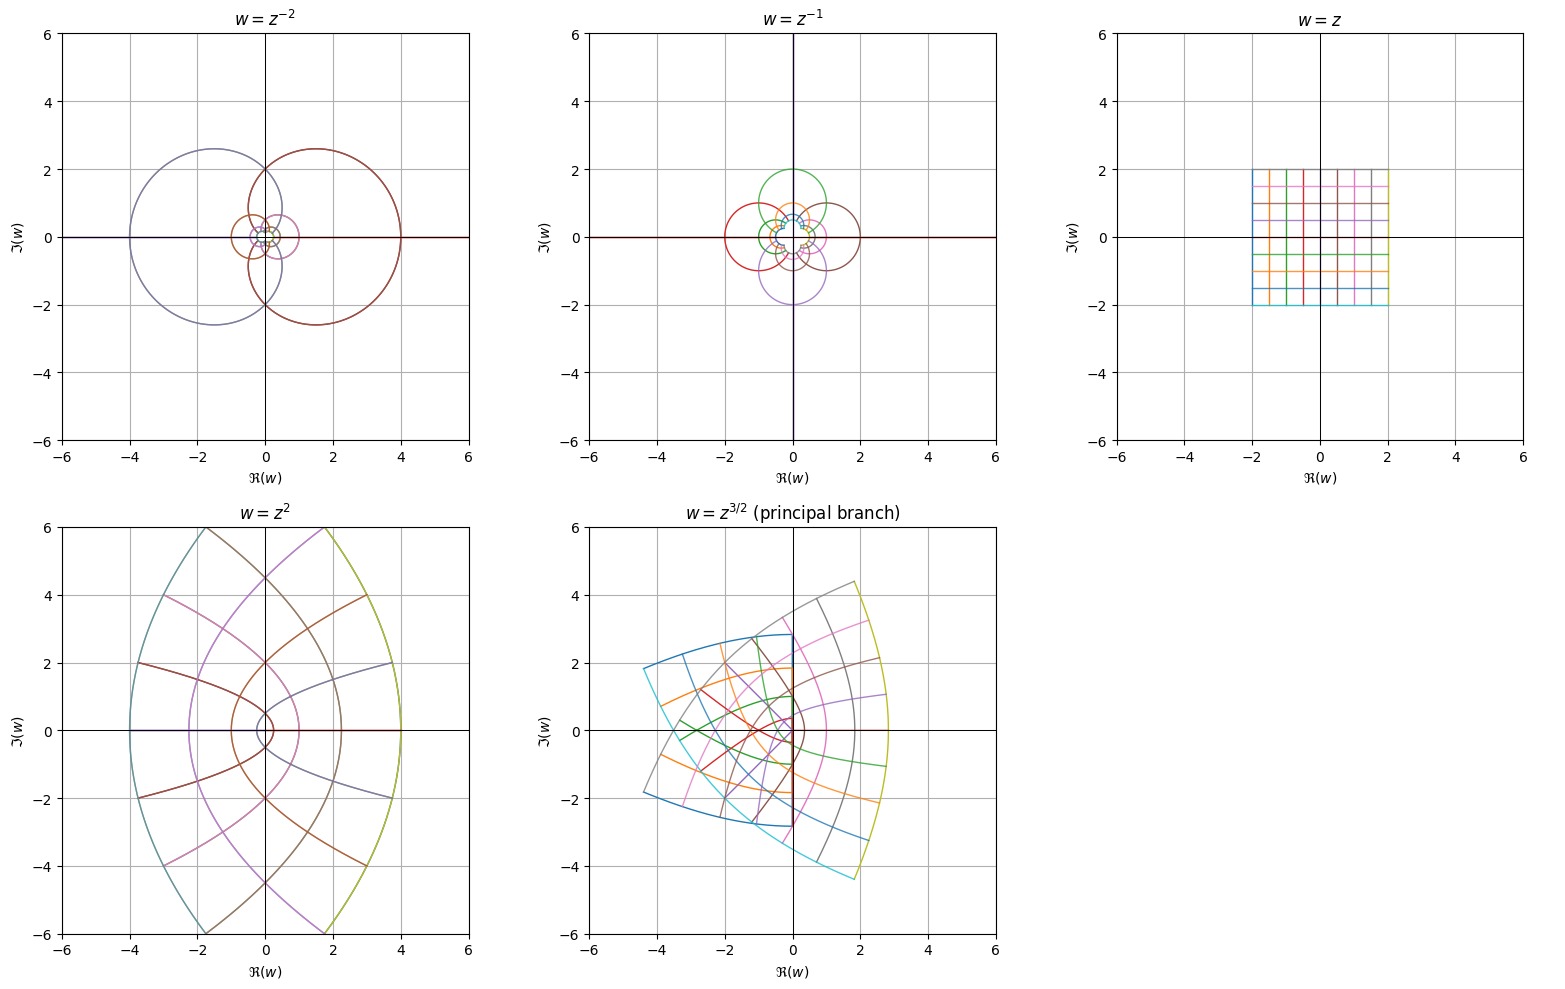

In [3]:

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

ns = [-2, -1, 1, 2, 1.5]
titles = [r"$w=z^{-2}$", r"$w=z^{-1}$", r"$w=z$", r"$w=z^2$", r"$w=z^{3/2}$ (principal branch)"]

for ax, n, ttl in zip(axes.flat, ns + [None], titles + [""]):
    if n is None:
        ax.axis("off")
        continue
    def f(z, n=n):
        return np.power(z, n)
    def mask(z, w):
        return np.isfinite(np.real(w)) & np.isfinite(np.imag(w)) & (np.abs(z) > 1e-6)
    plot_mapped_grid(f, xlim=(-2,2), ylim=(-2,2), n_lines=9, title=ttl, ax=ax, mask=mask)
    ax.set_xlim(-6,6)
    ax.set_ylim(-6,6)

plt.tight_layout()
plt.show()



**Description.**

- $w=z$: nothing changes.
- $w=z^2$: the angle doubles, so sectors spread out faster in angle; the origin is still the "special point."
- $w=z^{-1}$: circles/lines are inverted through the origin, and the singularity at $z=0$ blows up.
- $w=z^{-2}$: same inversion behavior, but with angle multiplied by $-2$.
- $w=z^{3/2}$: the argument is multiplied by $\tfrac32$, but because of the fractional exponent we must choose a branch. On the principal branch there is a branch cut along the negative real axis.


### 1.2 Logarithmic map: $w(z)=\log z$

Write

$$
z = r e^{i\theta}.
$$

Then

$$
w = \log z = \log r + i\theta
$$

on a chosen branch.

So:

- circles $r=\text{constant}$ map to vertical lines $\Re(w)=\log r$
- rays $\theta=\text{constant}$ map to horizontal lines $\Im(w)=\theta$

Again, this needs a branch choice. I use the principal branch, so

$$
-\pi < \arg z \le \pi.
$$

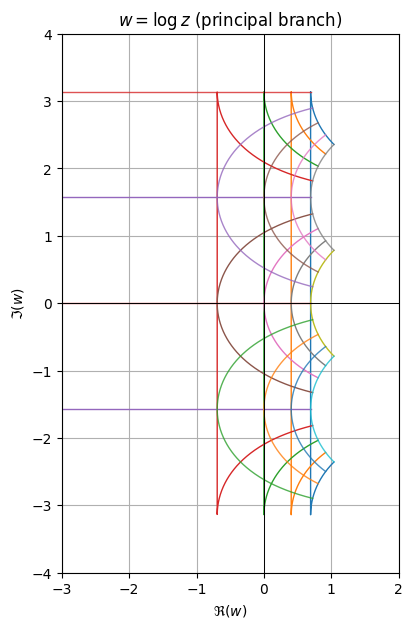

In [4]:

fig, ax = plt.subplots(figsize=(7,7))

def flog(z):
    return np.log(z)

def log_mask(z, w):
    return np.isfinite(np.real(w)) & np.isfinite(np.imag(w)) & (np.abs(z) > 1e-6)

# avoid crossing the branch cut too aggressively by using y-range that does not wrap too much
plot_mapped_grid(flog, xlim=(-2,2), ylim=(-2,2), n_lines=9, title=r"$w=\log z$ (principal branch)", ax=ax, mask=log_mask)
ax.set_xlim(-3, 2)
ax.set_ylim(-4, 4)
plt.show()



**Description.**

The logarithm, I guess you could say, "unravels" polar coordinates into rectangular coordinates:
$$
(\log r,\theta).
$$
So multiplicative radial structure becomes additive horizontal structure, and angle becomes height.


### 1.3 Trigonometric maps: $w(z)=\sin z$ and $w(z)=\cos z$

For $z = x + iy$,

$$
\sin z = \sin x \cosh y + i \cos x \sinh y,
$$

and

$$
\cos z = \cos x \cosh y - i \sin x \sinh y.
$$

So these maps are mixing trigonometric oscillation in $x$ with hyperbolic growth in $y$.

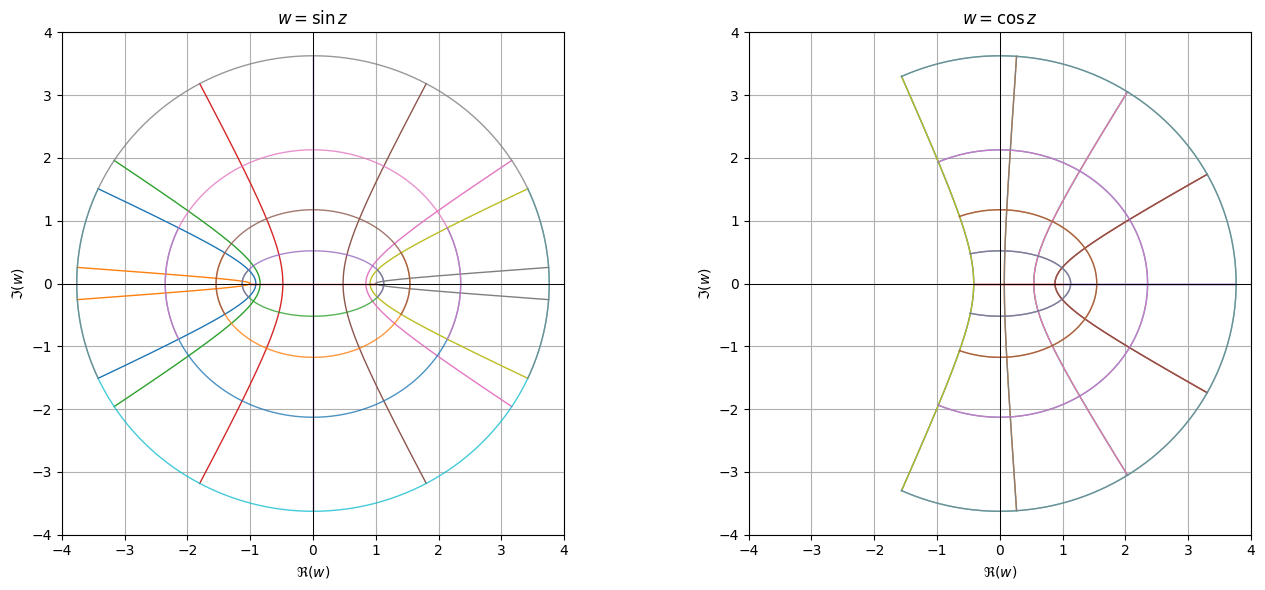

In [5]:

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

plot_mapped_grid(np.sin, xlim=(-2,2), ylim=(-2,2), n_lines=9, title=r"$w=\sin z$", ax=axes[0])
axes[0].set_xlim(-4,4)
axes[0].set_ylim(-4,4)

plot_mapped_grid(np.cos, xlim=(-2,2), ylim=(-2,2), n_lines=9, title=r"$w=\cos z$", ax=axes[1])
axes[1].set_xlim(-4,4)
axes[1].set_ylim(-4,4)

plt.tight_layout()
plt.show()



**Description.**

- $\sin z$ and $\cos z$ are holomorphic, so there is no branch cut or singularity.
- Horizontal and vertical lines bend into "families of curves" determined by the $\sin/\cos$ factors and the $\sinh/\cosh$ growth.
- The hyperbolic factors make the images stretch quickly as $|y|$ grows.


### 1.4 Square root maps: $w(z)=\sqrt{z}$ and $w(z)=\sqrt{1/z}$

For

$$
z = r e^{i\theta},
$$

the principal square root is

$$
\sqrt{z} = \sqrt{r}\, e^{i\theta/2}.
$$

So the angle is halved. This is why the square root map tends to “open up” angles. It is also multi-valued unless we choose a branch.

Also,

$$
\sqrt{\frac{1}{z}} = z^{-1/2} = r^{-1/2} e^{-i\theta/2},
$$

which combines inversion with angle-halving.

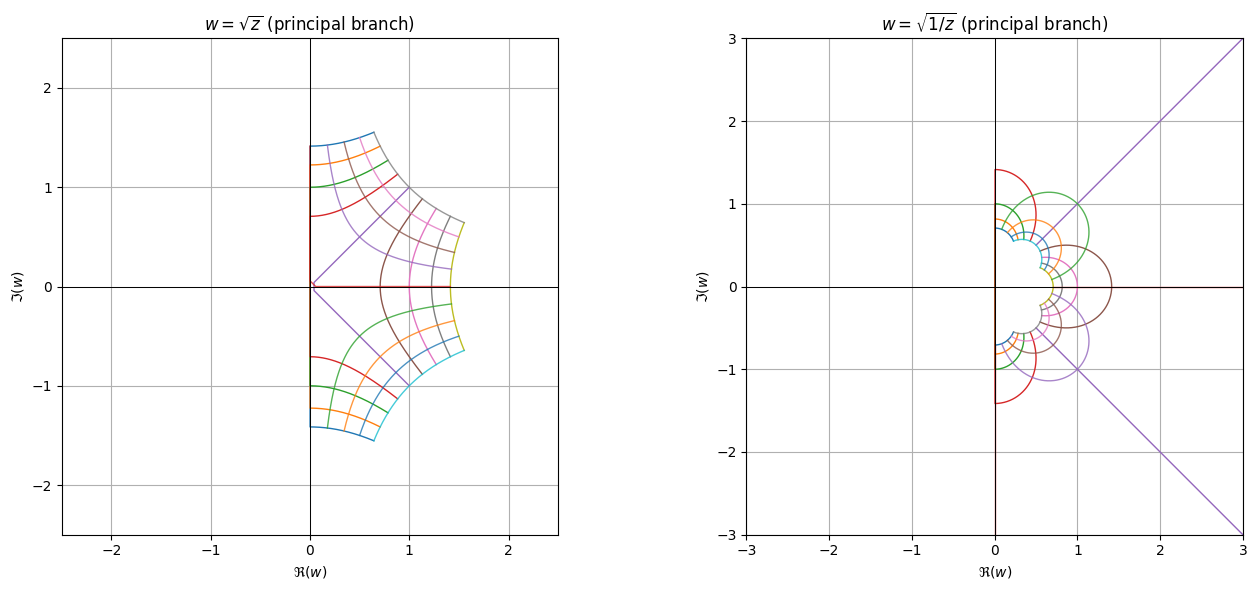

In [6]:

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

def fsqrt(z):
    return np.sqrt(z)

def finvsqrt(z):
    return np.sqrt(1/z)

def sqrt_mask(z, w):
    return np.isfinite(np.real(w)) & np.isfinite(np.imag(w)) & (np.abs(z) > 1e-6)

plot_mapped_grid(fsqrt, xlim=(-2,2), ylim=(-2,2), n_lines=9, title=r"$w=\sqrt{z}$ (principal branch)", ax=axes[0], mask=sqrt_mask)
axes[0].set_xlim(-2.5,2.5)
axes[0].set_ylim(-2.5,2.5)

plot_mapped_grid(finvsqrt, xlim=(-2,2), ylim=(-2,2), n_lines=9, title=r"$w=\sqrt{1/z}$ (principal branch)", ax=axes[1], mask=sqrt_mask)
axes[1].set_xlim(-3,3)
axes[1].set_ylim(-3,3)

plt.tight_layout()
plt.show()



**Description.**

- $\sqrt{z}$ halves angles and takes $r$ to $\sqrt{r}$.
- $\sqrt{1/z}$ also halves angles, but reverses radial size because of the $1/z$ factor.
- Both require a branch choice; here I used the principal branch.


---

## 2. Flow past a circular cylinder

The worksheet next asks me for two-dimensional potential flow past a circular cylinder.

Let

$$
\mathbf{u} = (u, v).
$$

We define the complex potential by

$$
W(z) = \phi(x,y) + i \psi(x,y),
$$

where $\phi$ is the velocity potential and $\psi$ is the streamfunction.

### 2.1 Why the velocity potential satisfies Laplace's equation

Assume the flow is irrotational:

$$
\nabla \times \mathbf{u} = 0.
$$

In two dimensions, this means

$$
\frac{\partial v}{\partial x} - \frac{\partial u}{\partial y} = 0.
$$

An irrotational vector field can be written as the gradient of a scalar potential:

$$
\mathbf{u} = \nabla \phi,
\qquad
u = \phi_x, \quad v = \phi_y.
$$

Now use this from class:

$$
\nabla \cdot \mathbf{u} = 0.
$$

Since $\mathbf{u} = \nabla \phi$, we get

$$
\nabla \cdot \mathbf{u}
= \nabla \cdot (\nabla \phi)
= \Delta \phi
= \phi_{xx} + \phi_{yy}
= 0.
$$

Therefore the velocity potential satisfies Laplace's equation:

$$
\boxed{\Delta \phi = 0.}
$$

### 2.2 Why the streamfunction satisfies Laplace's equation

For two-dimensional incompressible flow, define the streamfunction by

$$
u = \frac{\partial \psi}{\partial y},
\qquad
v = -\frac{\partial \psi}{\partial x}.
$$

First check this:

$$
u_x + v_y
= \psi_{yx} - \psi_{xy}
= 0,
$$

so this definition automatically enforces $\nabla \cdot \mathbf{u} = 0$.

Now impose irrotationality:

$$
\frac{\partial v}{\partial x} - \frac{\partial u}{\partial y} = 0.
$$

Substitute the streamfunction formulas:

$$
\frac{\partial}{\partial x}(-\psi_x) - \frac{\partial}{\partial y}(\psi_y) = 0,
$$

so

$$
-\psi_{xx} - \psi_{yy} = 0.
$$

Hence

$$
\boxed{\Delta \psi = 0.}
$$

So $\psi$ is also harmonic.

### 2.3 Cauchy–Riemann relations and the complex velocity

Because

$$
W(z) = \phi + i \psi
$$

is analytic, $\phi$ and $\psi$ satisfy the Cauchy–Riemann equations:

$$
\phi_x = \psi_y, \qquad \phi_y = -\psi_x.
$$

Using

$$
u = \phi_x, \qquad v = \phi_y,
$$

we get

$$
u = \psi_y, \qquad v = -\psi_x,
$$

as expected.

Also,

$$
\frac{dW}{dz}
= \phi_x + i \psi_x
= u - i v.
$$

So the complex derivative gives the complex velocity:

$$
\boxed{\frac{dW}{dz} = u - iv.}
$$

### 2.4 Uniform background flow: $W(z)=Uz$

Take

$$
W(z) = Uz, \qquad z = x + iy,
$$

with $U \in \mathbb{R}$.

Then

$$
W(z) = U(x + iy) = Ux + iUy.
$$

Therefore

$$
\phi(x,y) = Ux,
\qquad
\psi(x,y) = Uy.
$$

The velocity is

$$
u = \phi_x = U, \qquad v = \phi_y = 0,
$$

so this is a constant horizontal flow to the right.

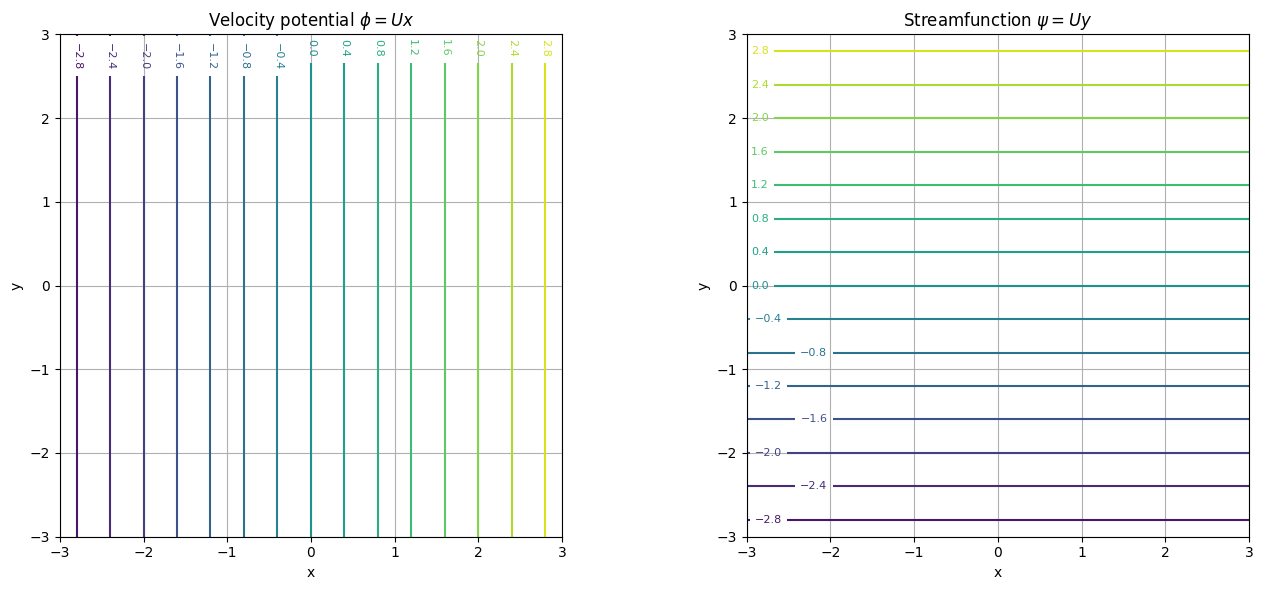

In [7]:

U = 1.0
x = np.linspace(-3, 3, 300)
y = np.linspace(-3, 3, 300)
X, Y = np.meshgrid(x, y)

phi_uniform = U * X
psi_uniform = U * Y

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

cs1 = axes[0].contour(X, Y, phi_uniform, levels=15)
axes[0].clabel(cs1, inline=True, fontsize=8)
axes[0].set_title(r"Velocity potential $\phi=Ux$")
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")
axes[0].set_aspect("equal")

cs2 = axes[1].contour(X, Y, psi_uniform, levels=15)
axes[1].clabel(cs2, inline=True, fontsize=8)
axes[1].set_title(r"Streamfunction $\psi=Uy$")
axes[1].set_xlabel("x")
axes[1].set_ylabel("y")
axes[1].set_aspect("equal")

plt.tight_layout()
plt.show()


### 2.5 Flow past a circular cylinder

The worksheet gives the complex potential

$$
W(z) = U\left(z + \frac{a^2}{z}\right),
$$

for flow outside the cylinder $|z| = a$. This is the standard potential for uniform flow past a cylinder.

Write

$$
z = r e^{i\theta}.
$$

Then

$$
\frac{1}{z} = \frac{1}{r} e^{-i\theta},
$$

so

$$
W(z) = U\left(r e^{i\theta} + \frac{a^2}{r} e^{-i\theta}\right).
$$

Expand:

$$
W(z)
=
U\left[\left(r + \frac{a^2}{r}\right)\cos\theta
+
i\left(r - \frac{a^2}{r}\right)\sin\theta\right].
$$

Therefore

$$
\boxed{
\phi(r,\theta) = U\left(r + \frac{a^2}{r}\right)\cos\theta
}
$$

and

$$
\boxed{
\psi(r,\theta) = U\left(r - \frac{a^2}{r}\right)\sin\theta.
}
$$

On the boundary $r = a$,

$$
\psi(a,\theta)
=
U\left(a - \frac{a^2}{a}\right)\sin\theta
=
0.
$$

So the cylinder surface is a streamline. Physically, that means fluid particles move tangent to the boundary and do not cross into the solid cylinder, which is exactly what we want for flow past an impermeable obstacle.

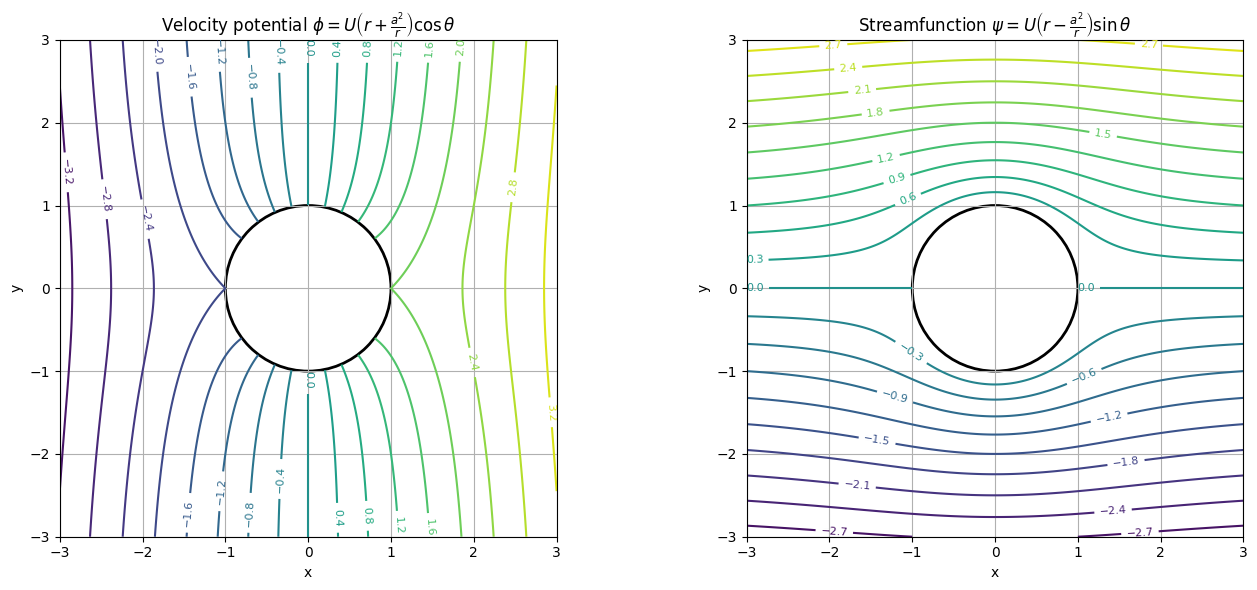

In [8]:

U = 1.0
a = 1.0

x = np.linspace(-3, 3, 500)
y = np.linspace(-3, 3, 500)
X, Y = np.meshgrid(x, y)
R = np.sqrt(X**2 + Y**2)
Theta = np.arctan2(Y, X)

phi = U * (R + a**2 / R) * np.cos(Theta)
psi = U * (R - a**2 / R) * np.sin(Theta)

mask = R <= a
phi = np.ma.array(phi, mask=mask)
psi = np.ma.array(psi, mask=mask)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

cs1 = axes[0].contour(X, Y, phi, levels=20)
axes[0].clabel(cs1, inline=True, fontsize=8)
circle = plt.Circle((0,0), a, fill=False, linewidth=2)
# I restrict going to the exterior region $r > a$ and mask the interior $r \le a$ to represent the solid cylinder request we talked about in class
axes[0].add_patch(circle)
axes[0].set_title(r"Velocity potential $\phi=U\left(r+\frac{a^2}{r}\right)\cos\theta$")
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")
axes[0].set_aspect("equal")
axes[0].set_xlim(-3,3)
axes[0].set_ylim(-3,3)

cs2 = axes[1].contour(X, Y, psi, levels=20)
axes[1].clabel(cs2, inline=True, fontsize=8)
circle = plt.Circle((0,0), a, fill=False, linewidth=2)
# I restrict going to the exterior region $r > a$ and mask the interior $r \le a$ to represent the solid cylinder request we talked about in class
axes[1].add_patch(circle)
axes[1].set_title(r"Streamfunction $\psi=U\left(r-\frac{a^2}{r}\right)\sin\theta$")
axes[1].set_xlabel("x")
axes[1].set_ylabel("y")
axes[1].set_aspect("equal")
axes[1].set_xlim(-3,3)
axes[1].set_ylim(-3,3)

plt.tight_layout()
plt.show()


### 2.6 Radial and tangential velocity components

In polar coordinates, the velocity potential gives

$$
u_r = \frac{\partial \phi}{\partial r},
\qquad
u_\theta = \frac{1}{r}\frac{\partial \phi}{\partial \theta}.
$$

Using

$$
\phi(r,\theta) = U\left(r + \frac{a^2}{r}\right)\cos\theta,
$$

we compute

$$
u_r
=
\frac{\partial \phi}{\partial r}
=
U\left(1 - \frac{a^2}{r^2}\right)\cos\theta,
$$

and

$$
u_\theta
=
\frac{1}{r}\frac{\partial \phi}{\partial \theta}
=
\frac{1}{r}\left[-U\left(r + \frac{a^2}{r}\right)\sin\theta\right]
=
-U\left(1 + \frac{a^2}{r^2}\right)\sin\theta.
$$

So

$$
\boxed{
u_r = U\left(1 - \frac{a^2}{r^2}\right)\cos\theta,
\qquad
u_\theta = -U\left(1 + \frac{a^2}{r^2}\right)\sin\theta.
}
$$

On the boundary $r = a$,

$$
u_r(a,\theta) = U(1 - 1)\cos\theta = 0.
$$

That means there is no normal velocity through the cylinder surface, so the boundary is impermeable. The tangential component generally does not vanish, so fluid can still slide along the cylinder.

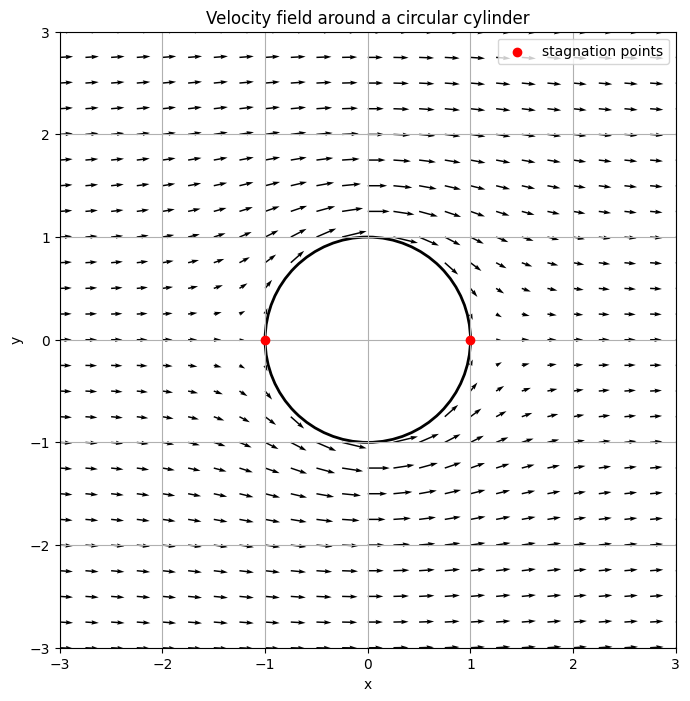

In [13]:

U = 1.0
a = 1.0

x = np.linspace(-3, 3, 25)
y = np.linspace(-3, 3, 25)
X, Y = np.meshgrid(x, y)
R = np.sqrt(X**2 + Y**2)
R[R < a] = np.nan
Theta = np.arctan2(Y, X)

ur = U * (1 - a**2 / R**2) * np.cos(Theta)
utheta = -U * (1 + a**2 / R**2) * np.sin(Theta)

u = ur * np.cos(Theta) - utheta * np.sin(Theta)
v = ur * np.sin(Theta) + utheta * np.cos(Theta)

u = np.where(R <= a, np.nan, u)
v = np.where(R <= a, np.nan, v)

fig, ax = plt.subplots(figsize=(8,8))
ax.quiver(X, Y, u, v)
circle = plt.Circle((0,0), a, fill=False, linewidth=2)
ax.add_patch(circle)
ax.scatter([a, -a], [0, 0], color='red', zorder=5, label='stagnation points')
ax.legend()
ax.set_title("Velocity field around a circular cylinder")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_aspect("equal")
ax.set_xlim(-3,3)
ax.set_ylim(-3,3)
plt.show()


### 2.7 Stagnation points

Stagnation points satisfy

$$
\frac{dW}{dz} = 0.
$$

For

$$
W(z) = U\left(z + \frac{a^2}{z}\right),
$$

we get

$$
\frac{dW}{dz}
=
U\left(1 - \frac{a^2}{z^2}\right).
$$

Set this equal to zero:

$$
1 - \frac{a^2}{z^2} = 0
\quad \Longrightarrow \quad
z^2 = a^2.
$$

Hence

$$
\boxed{z = \pm a.}
$$

So the stagnation points are at

$$
(a,0) \quad \text{and} \quad (-a,0),
$$

the front and rear points of the cylinder on the horizontal axis.

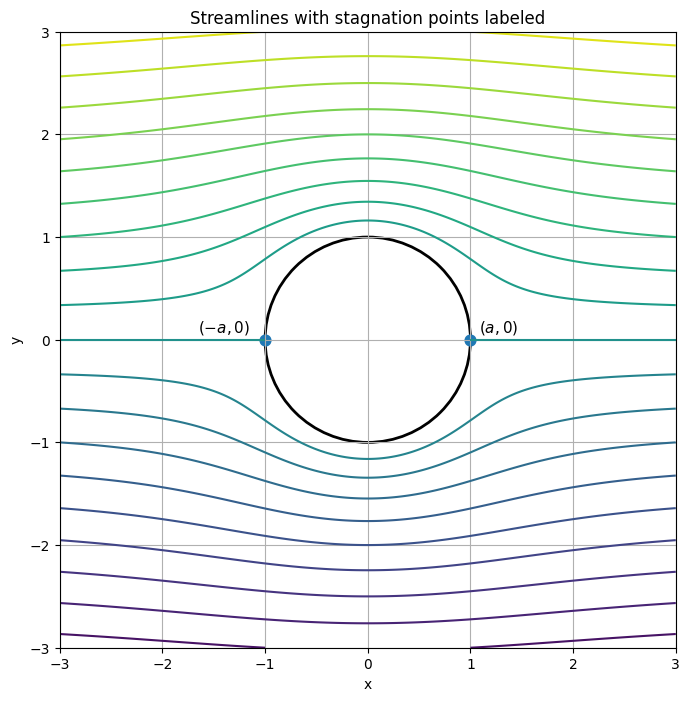

In [10]:

U = 1.0
a = 1.0

x = np.linspace(-3, 3, 400)
y = np.linspace(-3, 3, 400)
X, Y = np.meshgrid(x, y)
R = np.sqrt(X**2 + Y**2)
Theta = np.arctan2(Y, X)

psi = U * (R - a**2 / R) * np.sin(Theta)
psi = np.ma.array(psi, mask=R <= a)

fig, ax = plt.subplots(figsize=(8,8))
ax.contour(X, Y, psi, levels=20)
circle = plt.Circle((0,0), a, fill=False, linewidth=2)
ax.add_patch(circle)

stagnation = np.array([[a,0],[-a,0]])
ax.scatter(stagnation[:,0], stagnation[:,1], s=60)
ax.text(a+0.08, 0.08, r"$(a,0)$", fontsize=11)
ax.text(-a-0.65, 0.08, r"$(-a,0)$", fontsize=11)

ax.set_title("Streamlines with stagnation points labeled")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_aspect("equal")
ax.set_xlim(-3,3)
ax.set_ylim(-3,3)
plt.show()


## Final summary

- For the conformal maps, the main idea is to track what happens to the modulus and argument.
- For the logarithm and square root, a branch choice is necessary.
- For the cylinder flow,

$$
W(z) = U\left(z + \frac{a^2}{z}\right)
$$

gives

$$
\phi = U\left(r + \frac{a^2}{r}\right)\cos\theta,
\qquad
\psi = U\left(r - \frac{a^2}{r}\right)\sin\theta.
$$

- The cylinder boundary $r = a$ is a streamline since $\psi = 0$ there.
- The radial velocity vanishes on the boundary, so there is no flow through the cylinder.
- The stagnation points are at $z = \pm a$.